# Imports

In [16]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','no-latex'])

In [3]:
seed = 69
rng = np.random.default_rng(seed)


## Load & prepare the S&P 500 price panel

Keep only stocks that already existed on the first date; the residual `NaN`s that
remain are the *real* missingness the thesis imputes.

In [4]:

CSV = Path("../Data/sp500_prices.csv")

prices = pd.read_csv(CSV, index_col="Date", parse_dates=["Date"]).sort_index()

# Eliminate stocks that did not exist at the start date (NaN on the first day)
prices = prices.loc[:, prices.iloc[0].notna()]

# Daily simple returns -- the panel the imputation / portfolio analysis runs on
returns = prices.pct_change().iloc[1:]

print(f"{prices.shape[1]} stocks survive from {prices.index[0].date()} "
      f"to {prices.index[-1].date()}  ({len(prices)} trading days)")
print(f"residual missingness (real gaps to impute): "
      f"{returns.isna().mean().mean():.2%}")
prices.iloc[:3, :5]

422 stocks survive from 2010-01-04 to 2026-05-29  (4126 trading days)
residual missingness (real gaps to impute): 0.00%


,A,AAPL,ABT,ACGL,ACN
Date,,,,,
2010-01-04,19.810984,6.406480,18.207747,7.601905,31.227354
2010-01-05,19.595781,6.417557,18.060642,7.576549,31.420353
2010-01-06,19.526159,6.315477,18.160942,7.543795,31.754366


## Choose 50 stocks

Choose a smaller, nimbler sample of stocks stratified across sectors

In [5]:
tickers_50 = [
    # Information Technology
    "AAPL", "MSFT", "ORCL", "CSCO", "IBM", "INTC", "TXN",
    # Financials
    "JPM", "BAC", "WFC", "GS", "MS", "AXP",
    # Communication Services
    "GOOGL", "DIS", "CMCSA", "VZ",
    # Consumer Discretionary
    "AMZN", "HD", "MCD", "NKE", "LOW",
    # Health Care
    "JNJ", "MRK", "PFE", "UNH", "ABT", "AMGN",
    # Industrials
    "CAT", "HON", "UPS", "UNP", "LMT", "MMM",
    # Consumer Staples
    "PG", "KO", "PEP", "WMT", "COST",
    # Energy
    "XOM", "CVX", "COP", "SLB",
    # Utilities
    "NEE", "DUK", "SO",
    # Materials
    "SHW", "APD",
    # Real Estate
    "AMT", "PLD"
]

sample = prices[tickers_50]
log_sample = np.log(sample)
log_returns = log_sample.diff().iloc[1:]

## Inject realistic missingness

Three independently tunable styles applied to the dense panel:

- **Sparse** isolated entries — one asset missing at scattered dates (`add_sparse`, `rate`).
- **Contiguous gaps** — an asset missing for many consecutive periods (`add_gaps`, `n`, `mean_len`).
- **Whole missing rows** — a date with no observations: holidays, calendar mismatch, DB outages (`add_missing_rows`, `rate`).

Because the base panel is dense, `mask = miss.isna()` is exactly the set of hidden cells — the evaluation mask to score imputation against.

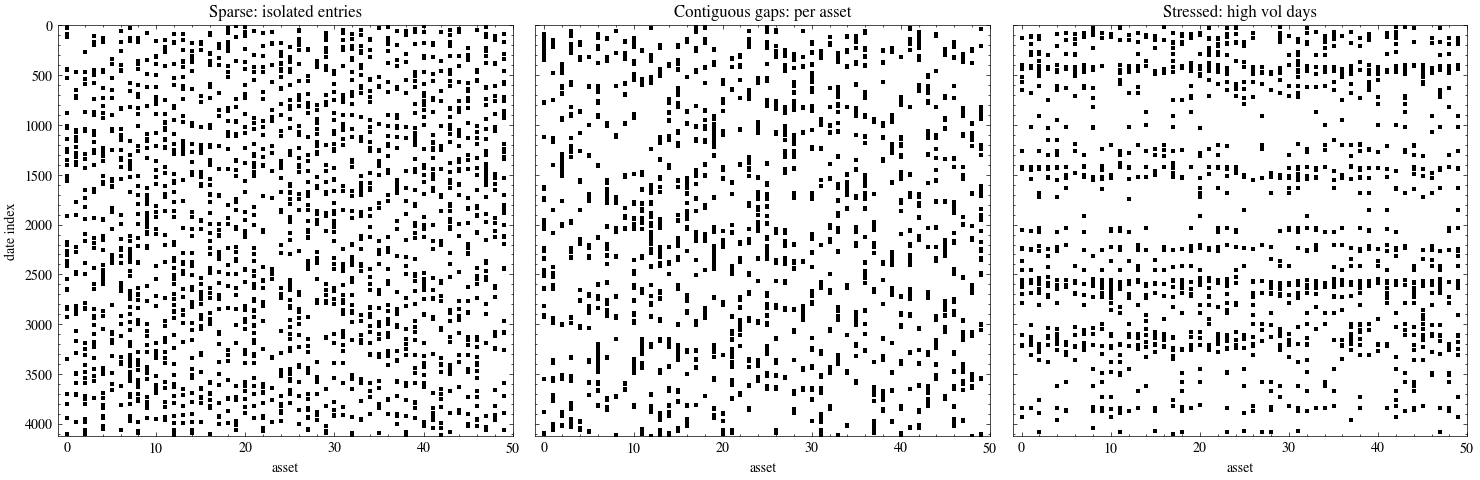

In [26]:
def add_sparse(df, rate=0.02):        # isolated entries: one asset at scattered dates
    return df.mask(rng.random(df.shape) < rate)

def add_gaps(df, n=25, mean_len=15):  # contiguous gaps: long runs per asset
    X = df.copy(); T, N = X.shape
    for _ in range(n):
        j, t0 = rng.integers(N), rng.integers(T)
        X.iloc[t0:t0 + max(1, int(rng.exponential(mean_len))), j] = np.nan
    return X

def stress_mask(
    X: pd.DataFrame,
    base_q: float = 0.05,
    stress_q: float = 0.25,
    stress_quantile: float = 0.90,
    seed: int = 3
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    X = np.log(X).diff().iloc[1:]  # log returns

    market_proxy = X.mean(axis=1)

    stress_score = market_proxy ** 2

    threshold = stress_score.quantile(stress_quantile)
    stress_days = stress_score >= threshold

    probs = pd.Series(float(base_q), index=X.index)
    probs.loc[stress_days] = stress_q

    random_matrix = rng.random(X.shape)
    prob_matrix = np.repeat(probs.values[:, None], X.shape[1], axis=1)

    mask = random_matrix < prob_matrix
    return pd.DataFrame(mask, index=X.index, columns=X.columns)

ex = sample
examples = {
    "Sparse: isolated entries":    add_sparse(ex, rate=0.01).isna(),
    "Contiguous gaps: per asset":  add_gaps(ex, n=1000, mean_len=20).isna(),
    "Stressed: high vol days":   stress_mask(ex, base_q=0, stress_q=0.07, stress_quantile=0.90, seed=3),
}

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)
for ax, (title, m) in zip(axes, examples.items()):
    ys, xs = np.nonzero(m.to_numpy())                  # markers, not pixels
    ax.scatter(xs, ys, s=5, marker="s", c="k", linewidths=0)
    ax.set(xlim=(-1, m.shape[1]), ylim=(m.shape[0], -1), xlabel="asset",
           title=f"{title}")
axes[0].set_ylabel("date index")
plt.tight_layout(); plt.show()
